# License plate detection with YOLOv8

**Object detection** combines classification and localization: for every object in an image, the model returns a class and a bounding box. This notebook evaluates a **YOLOv8** detector fine-tuned to find license plates, and looks beyond a single score to understand what it gets right and where it fails.

The model (`models/license_plate_yolov8s.pt`) was obtained by fine-tuning YOLOv8-small, pre-trained on the COCO dataset, on 25,470 annotated photos of vehicles. Training ran for a single epoch on a laptop CPU (about 3.4 hours). This notebook does not retrain it; it measures how good that one epoch already is.

The data are the *Large License Plate Detection Dataset* from Kaggle (public domain, about 2.5 GB). The next cell downloads it if it is not already in `data/license_plates`.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

plt.rcParams["figure.dpi"] = 100
DATA = Path("data/license_plates")

if not (DATA / "test").exists():
    import kagglehub                           # pip install kagglehub
    root = Path(kagglehub.dataset_download("fareselmenshawii/large-license-plate-dataset"))
    for split in ("train", "val", "test"):
        (DATA / split).mkdir(parents=True, exist_ok=True)
        for kind in ("images", "labels"):
            for f in (root / kind / split).iterdir():
                (DATA / split / f.name).symlink_to(f)

test_images = sorted((DATA / "test").glob("*.jpg"))
print(f"test images: {len(test_images)}, validation images: {len(list((DATA / 'val').glob('*.jpg')))}")

test images: 386, validation images: 1073


## 1. The data

Each image has a text file with one line per plate: `class x_center y_center width height`, with coordinates relative to the image size (YOLO format). There is a single class, *licensePlate*.

512 plates in 386 test images; images with more than one plate: 90


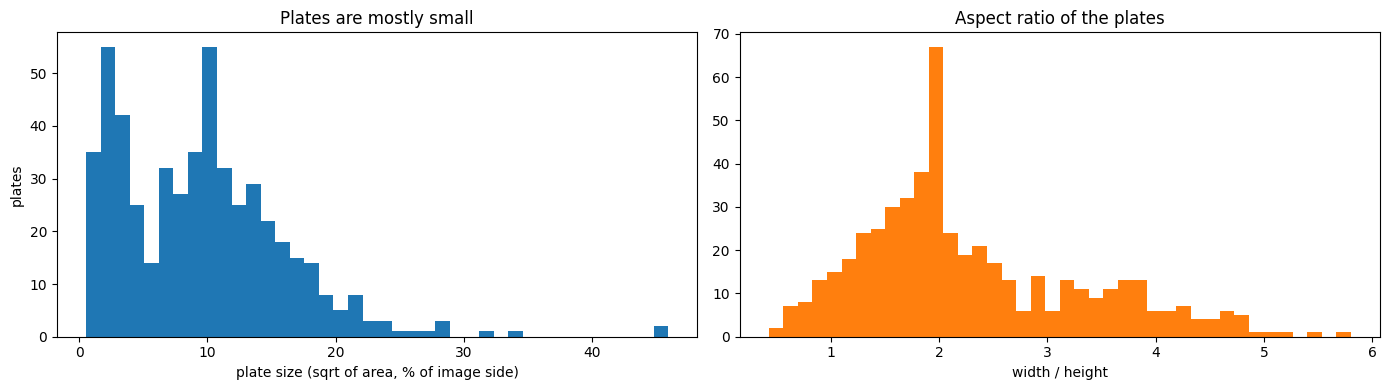

,width_px,height_px
count,512.0,512.0
mean,127.0,58.0
std,98.0,41.0
min,6.0,4.0
25%,45.0,27.0
50%,114.0,52.0
75%,175.0,80.0
max,825.0,313.0


In [2]:
def read_boxes(image_path):
    """Ground-truth boxes in pixels (x1, y1, x2, y2)."""
    w, h = Image.open(image_path).size
    label_file = image_path.with_suffix(".txt")
    if not label_file.exists() or label_file.stat().st_size == 0:
        return np.zeros((0, 4))
    _, xc, yc, bw, bh = np.loadtxt(label_file, ndmin=2).T
    return np.stack([(xc - bw / 2) * w, (yc - bh / 2) * h, (xc + bw / 2) * w, (yc + bh / 2) * h], 1)

gt = {p.name: read_boxes(p) for p in test_images}
sizes = {p.name: Image.open(p).size for p in test_images}
boxes = pd.DataFrame([
    {"image": name, "width_px": b[2] - b[0], "height_px": b[3] - b[1],
     "relative_area": (b[2] - b[0]) * (b[3] - b[1]) / (sizes[name][0] * sizes[name][1])}
    for name, bs in gt.items() for b in bs
])
print(f"{len(boxes)} plates in {len(gt)} test images; images with more than one plate: {(boxes.groupby('image').size() > 1).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(np.sqrt(boxes["relative_area"]) * 100, bins=40, color="tab:blue")
axes[0].set(xlabel="plate size (sqrt of area, % of image side)", ylabel="plates", title="Plates are mostly small")
axes[1].hist(boxes["width_px"] / boxes["height_px"], bins=40, color="tab:orange")
axes[1].set(xlabel="width / height", title="Aspect ratio of the plates")
fig.tight_layout()
plt.show()
boxes[["width_px", "height_px"]].describe().round(0)

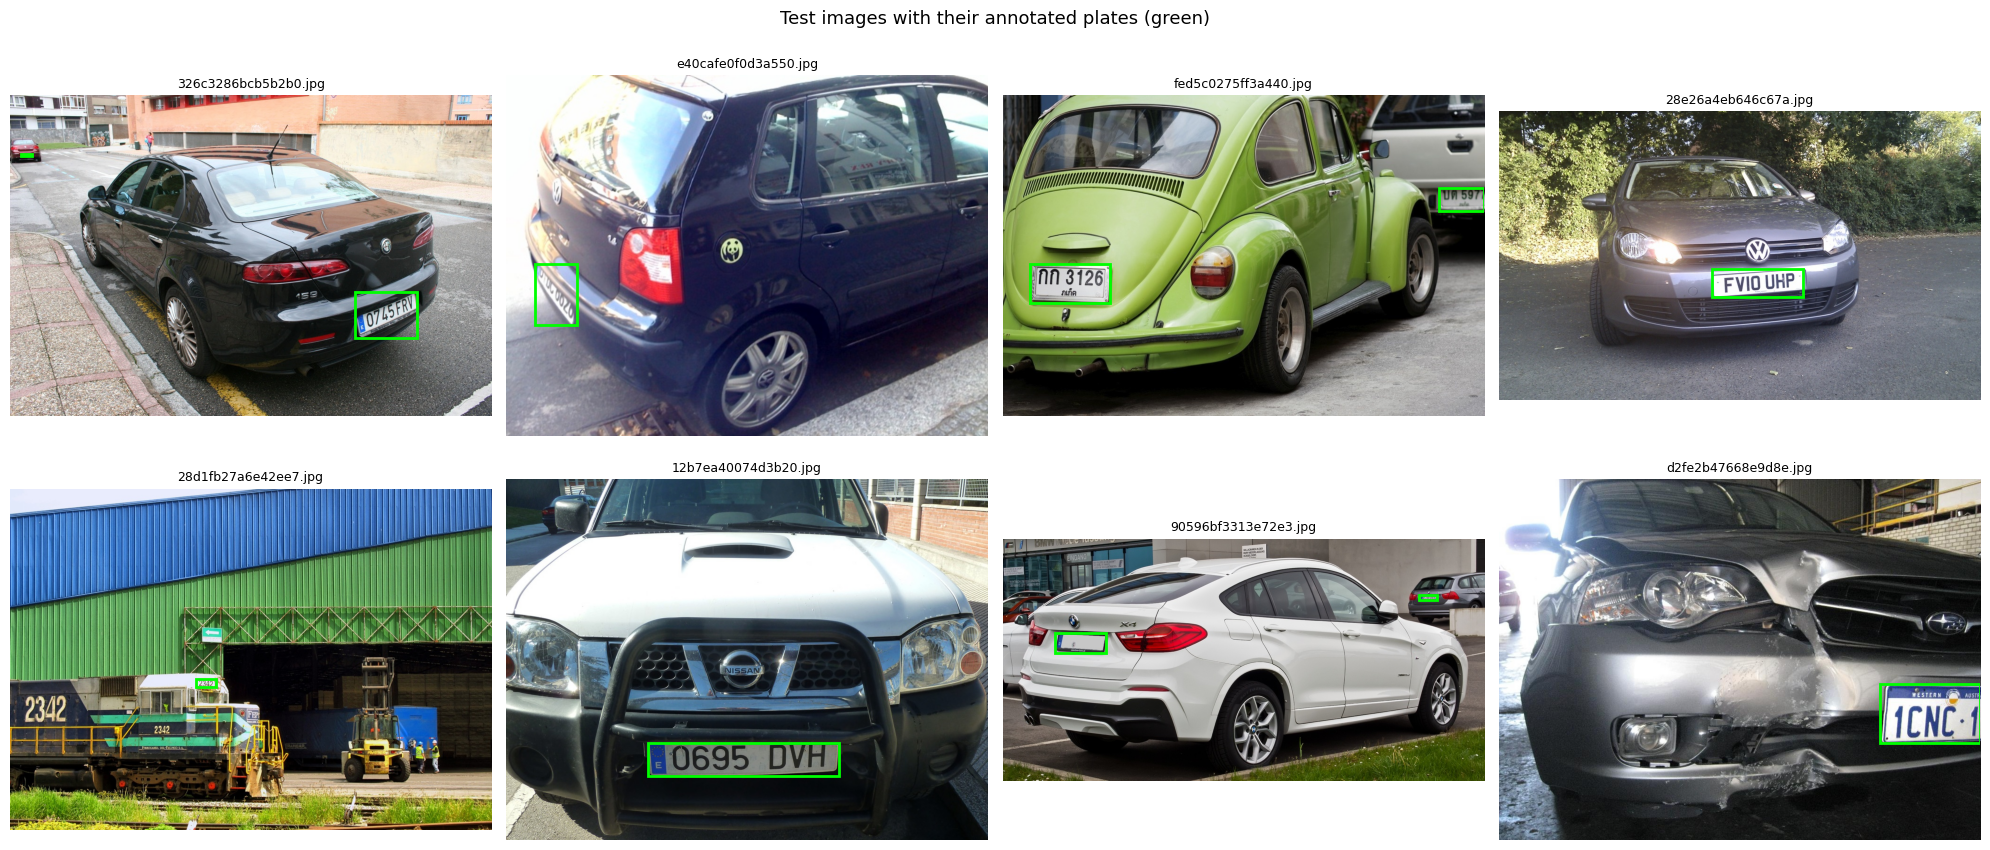

In [3]:
def draw_boxes(ax, image_path, gt_boxes=(), pred=(), title=""):
    ax.imshow(Image.open(image_path))
    for x1, y1, x2, y2 in gt_boxes:
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color="lime", lw=2))
    for x1, y1, x2, y2, conf in pred:
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color="red", lw=1.5, ls="--"))
        ax.text(x1, y1 - 3, f"{conf:.2f}", color="red", fontsize=9, weight="bold")
    ax.set_title(title, fontsize=9)
    ax.axis("off")

rng = np.random.default_rng(3)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, p in zip(axes.flat, rng.choice(test_images, 8, replace=False)):
    draw_boxes(ax, p, gt[p.name], title=p.name)
fig.suptitle("Test images with their annotated plates (green)", fontsize=13)
fig.tight_layout()
plt.show()

The test set contains 512 plates in 386 photos, from many countries, at very different distances. Plates are usually small: half of them are narrower than 115 pixels, and some are only a few pixels across, on cars far in the background. About a quarter of the images contain more than one plate.

## 2. How the model was trained

YOLO ("you only look once") predicts all boxes in a single forward pass: a convolutional backbone extracts features at three scales, and a detection head predicts, for every location of each feature map, whether an object is centred there, its box, and its class. Starting from weights pre-trained on COCO (80 everyday object classes, including cars), fine-tuning only has to teach the network a new class: the low-level features (edges, characters, rectangles) are already there. This **transfer learning** is what makes a single epoch useful.

The training log of that epoch:

In [4]:
log = pd.read_csv("models/training_results.csv")
log.columns = log.columns.str.strip()
log[["epoch", "time", "train/box_loss", "train/cls_loss", "metrics/precision(B)", "metrics/recall(B)",
     "metrics/mAP50(B)", "metrics/mAP50-95(B)"]].assign(time=lambda d: (d["time"] / 3600).round(2).astype(str) + " h").T

,0
epoch,1
time,3.38 h
train/box_loss,1.24827
train/cls_loss,0.96111
metrics/precision(B),0.8154
metrics/recall(B),0.70482
metrics/mAP50(B),0.75488
metrics/mAP50-95(B),0.38286


The validation metrics computed at the end of training are:

- **precision**: the share of predicted boxes that are real plates;
- **recall**: the share of real plates that are found;
- **mAP50**: the area under the precision-recall curve, counting a prediction as correct if its **intersection over union** (IoU) with a true box is at least 0.5;
- **mAP50-95**: the same averaged over IoU thresholds from 0.5 to 0.95, which also rewards precise box placement.

## 3. Evaluation on the test set

We now evaluate on the 386 test images, which were not used for training or model selection. We run the model with a very low confidence threshold to keep every candidate box, and match predictions to ground-truth plates ourselves, so that we can study the trade-off between precision and recall.

In [5]:
model = YOLO("models/license_plate_yolov8s.pt")
predictions = {}
for p in test_images:
    result = model.predict(p, conf=0.01, verbose=False)[0]
    xyxy = result.boxes.xyxy.numpy()
    predictions[p.name] = np.column_stack([xyxy, result.boxes.conf.numpy()]) if len(xyxy) else np.zeros((0, 5))
print(f"candidate boxes at confidence >= 0.01: {sum(len(v) for v in predictions.values())}")

candidate boxes at confidence >= 0.01: 1722


In [6]:
def iou(a, b):
    """IoU between every box in a (n, 4) and every box in b (m, 4)."""
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    area = lambda r: (r[:, 2] - r[:, 0]) * (r[:, 3] - r[:, 1])
    return inter / (area(a)[:, None] + area(b)[None, :] - inter)

def match(pred, truth, iou_threshold=0.5):
    """Greedy matching by decreasing confidence. Returns a true-positive flag per prediction and the matched IoUs."""
    order = np.argsort(-pred[:, 4])
    tp, used, ious = np.zeros(len(pred), bool), np.zeros(len(truth), bool), []
    if len(truth) and len(pred):
        overlap = iou(pred[order, :4], truth)
        for rank, i in enumerate(order):
            j = np.argmax(np.where(used, -1, overlap[rank]))
            if overlap[rank, j] >= iou_threshold and not used[j]:
                tp[i], used[j] = True, True
                ious.append(overlap[rank, j])
    return tp, ious

records = []
for name, pred in predictions.items():
    tp, _ = match(pred, gt[name])
    records += [{"image": name, "confidence": c, "tp": t} for c, t in zip(pred[:, 4], tp)]
records = pd.DataFrame(records).sort_values("confidence", ascending=False)
n_plates = sum(len(v) for v in gt.values())

records["precision"] = records["tp"].cumsum() / np.arange(1, len(records) + 1)
records["recall"] = records["tp"].cumsum() / n_plates
records["f1"] = 2 * records["precision"] * records["recall"] / (records["precision"] + records["recall"])

# Average precision: area under the interpolated precision-recall curve
prec_interp = np.maximum.accumulate(records["precision"].to_numpy()[::-1])[::-1]
ap50 = np.sum(np.diff(np.r_[0, records["recall"].to_numpy()]) * prec_interp)
best = records.loc[records["f1"].idxmax()]
print(f"AP at IoU 0.5 on the test set: {ap50:.3f}")
print(f"best F1 = {best['f1']:.3f} at confidence {best['confidence']:.2f} (precision {best['precision']:.3f}, recall {best['recall']:.3f})")
print(f"maximum recall reachable at any threshold: {records['recall'].max():.3f}")

AP at IoU 0.5 on the test set: 0.861
best F1 = 0.849 at confidence 0.30 (precision 0.881, recall 0.820)
maximum recall reachable at any threshold: 0.908


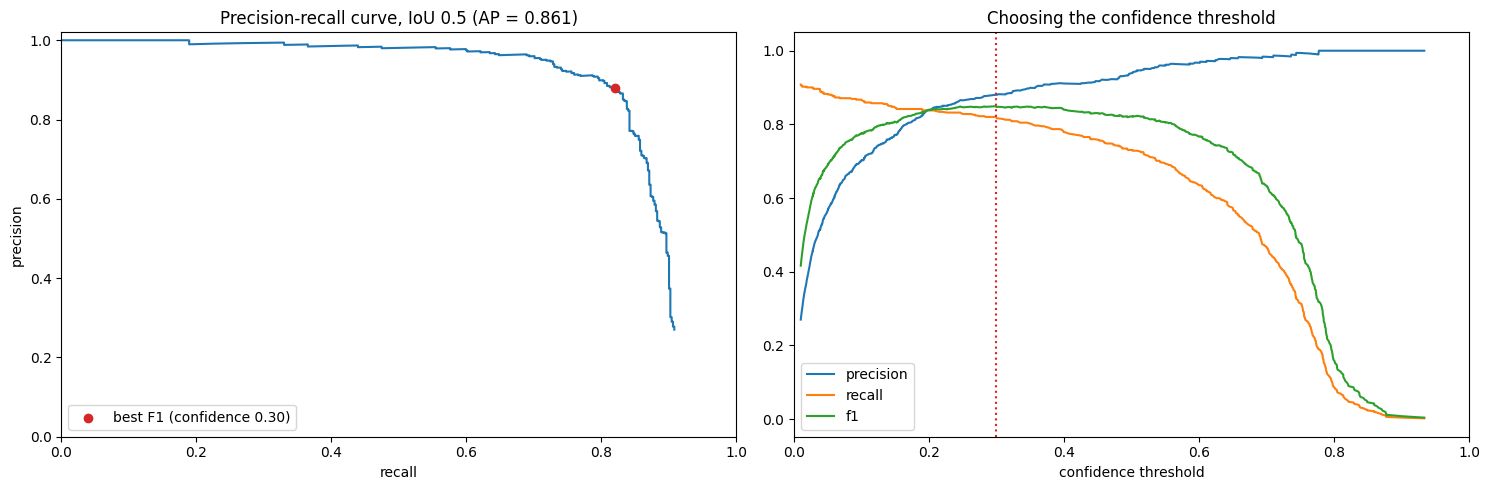

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(records["recall"], records["precision"], color="tab:blue")
ax1.scatter(best["recall"], best["precision"], color="tab:red", zorder=3, label=f"best F1 (confidence {best['confidence']:.2f})")
ax1.set(xlabel="recall", ylabel="precision", title=f"Precision-recall curve, IoU 0.5 (AP = {ap50:.3f})", xlim=(0, 1), ylim=(0, 1.02))
ax1.legend()
for col, color in [("precision", "tab:blue"), ("recall", "tab:orange"), ("f1", "tab:green")]:
    ax2.plot(records["confidence"], records[col], color=color, label=col)
ax2.axvline(best["confidence"], color="tab:red", ls=":")
ax2.set(xlabel="confidence threshold", title="Choosing the confidence threshold", xlim=(0, 1))
ax2.legend()
fig.tight_layout()
plt.show()

On the test set the detector reaches an **AP of 0.86** at IoU 0.5, higher than the 0.75 measured on the validation set at the end of training (the two sets differ in composition, so they are not directly comparable).

The precision-recall curve shows the trade-off offered by the confidence threshold. With a threshold of **0.30**, which maximizes F1, the detector finds **82%** of the plates and 88% of its detections are correct. Lowering the threshold finds more plates, but even at the lowest threshold about 9% of the plates are never detected at all: the model simply does not produce a candidate box for them.

### Which plates are missed?

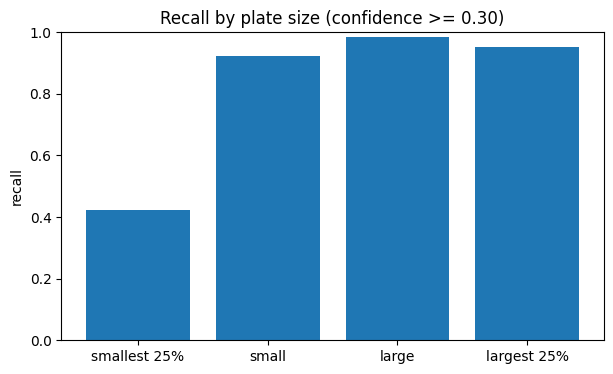

,plates,recall,median_size_pct
size group,,,
smallest 25%,128,0.422,2.300
small,128,0.922,7.058
large,128,0.984,10.742
largest 25%,128,0.953,16.592


In [8]:
threshold = best["confidence"]
rows = []
for name, truth in gt.items():
    pred = predictions[name][predictions[name][:, 4] >= threshold]
    overlap = iou(truth, pred[:, :4]) if len(pred) and len(truth) else np.zeros((len(truth), 0))
    w, h = sizes[name]
    for k, b in enumerate(truth):
        rows.append({"size_pct": 100 * np.sqrt((b[2] - b[0]) * (b[3] - b[1]) / (w * h)),
                     "found": overlap.shape[1] > 0 and overlap[k].max() >= 0.5,
                     "best_iou": overlap[k].max() if overlap.shape[1] else 0.0})
plates = pd.DataFrame(rows)
plates["size group"] = pd.qcut(plates["size_pct"], 4, labels=["smallest 25%", "small", "large", "largest 25%"])
by_size = plates.groupby("size group", observed=True).agg(plates=("found", "size"), recall=("found", "mean"),
                                                        median_size_pct=("size_pct", "median"))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(by_size.index.astype(str), by_size["recall"], color="tab:blue")
ax.set(ylabel="recall", ylim=(0, 1), title=f"Recall by plate size (confidence >= {threshold:.2f})")
plt.show()
by_size.round(3)

images with at least one missed plate: 70, with at least one false detection: 51


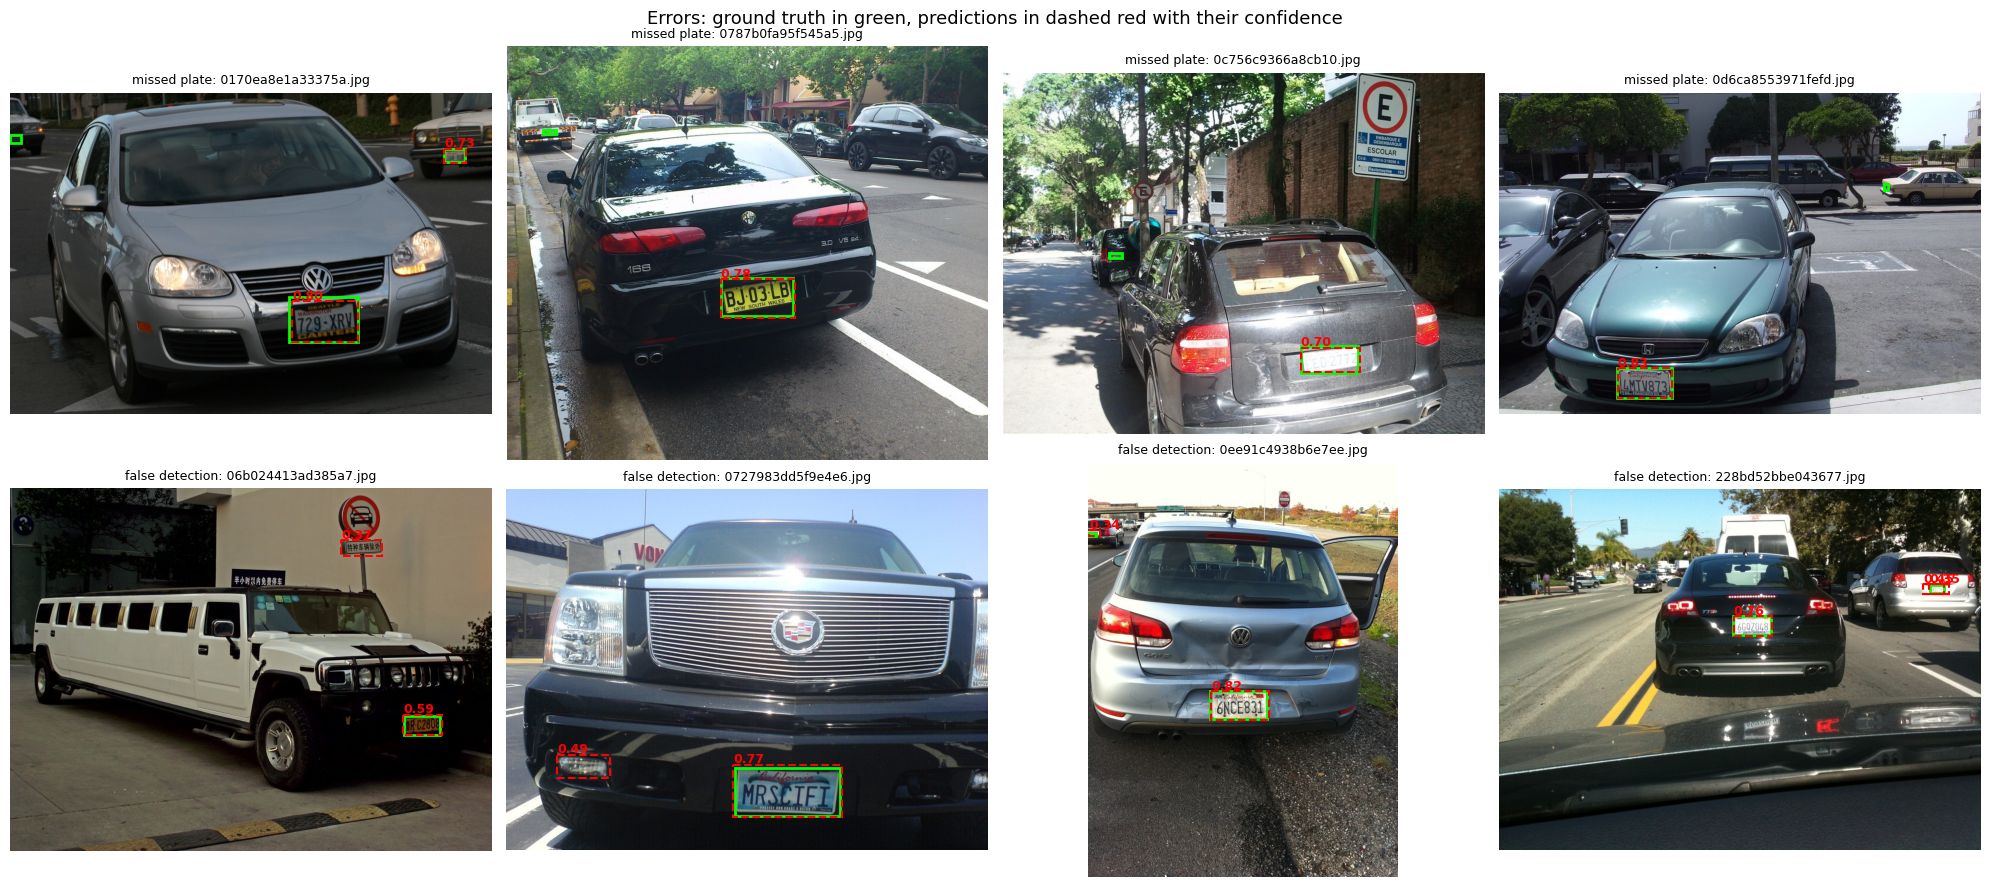

In [9]:
missed, false_pos = [], []
for name, truth in gt.items():
    pred = predictions[name][predictions[name][:, 4] >= threshold]
    tp, _ = match(pred, truth)
    found = iou(truth, pred[tp, :4]).max(1) >= 0.5 if tp.any() and len(truth) else np.zeros(len(truth), bool)
    if (~found).any():
        missed.append(name)
    if (~tp).any():
        false_pos.append(name)
print(f"images with at least one missed plate: {len(missed)}, with at least one false detection: {len(false_pos)}")

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, name in zip(axes[0], missed[:4]):
    pred = predictions[name][predictions[name][:, 4] >= threshold]
    draw_boxes(ax, DATA / "test" / name, gt[name], pred, title=f"missed plate: {name}")
for ax, name in zip(axes[1], false_pos[:4]):
    pred = predictions[name][predictions[name][:, 4] >= threshold]
    draw_boxes(ax, DATA / "test" / name, gt[name], pred, title=f"false detection: {name}")
fig.suptitle("Errors: ground truth in green, predictions in dashed red with their confidence", fontsize=13)
fig.tight_layout()
plt.show()

The breakdown by size is the clearest finding of the notebook. For plates of normal size the detector is excellent, with recall between 92% and 98%. For the **smallest quarter** of plates (about 2% of the image side, a few pixels wide once the image is resized to 640 pixels) recall drops to **42%**. The missed plates in the top row are exactly these: plates on cars in the background, while the main plate is found every time.

The false detections (bottom row) are mostly objects that look like plates: a rectangular sign with characters on it, a fog light housing, or a second, poorly placed box on a small distant plate. Their confidence is usually lower than that of real plates, which is why a moderate threshold removes most of them.

### Cropping the plates

The last step of a plate-reading system is to crop each detected plate for a character recognition (OCR) stage:

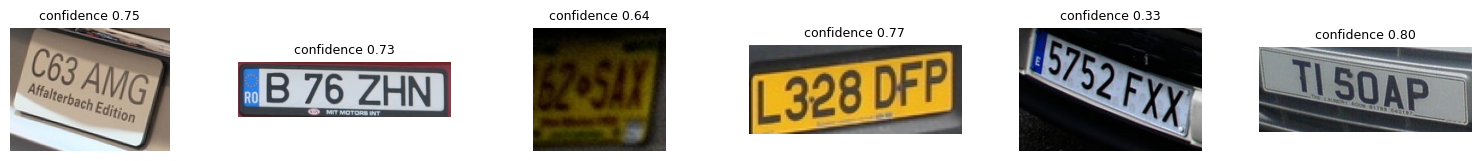

In [10]:
good = [n for n in gt if n not in missed and n not in false_pos and len(gt[n]) == 1][:6]
fig, axes = plt.subplots(1, len(good), figsize=(3.2 * len(good), 1.6))
for ax, name in zip(axes, good):
    pred = predictions[name][predictions[name][:, 4] >= threshold]
    x1, y1, x2, y2, conf = pred[np.argmax(pred[:, 4])]
    ax.imshow(Image.open(DATA / "test" / name).crop((int(x1), int(y1), int(x2), int(y2))))
    ax.set_title(f"confidence {conf:.2f}", fontsize=9)
    ax.axis("off")
plt.show()

## Summary

- Fine-tuning a detector **pre-trained on COCO** for a new class works remarkably well: a single epoch on a CPU already gives a usable plate detector.
- A single metric hides the trade-offs. The **precision-recall curve** shows how the confidence threshold trades missed plates for false alarms, and the F1-optimal threshold is a reasonable default.
- Breaking recall down by object size shows that the remaining errors concentrate on **small and distant plates**. That is where more training epochs, a larger input resolution, or a larger model would help most.
- The **false detections** are plate-like objects (signs with text, lights), usually with lower confidence than real plates.